<a href="https://colab.research.google.com/github/PalQuisp/Sis420-int/blob/main/presentar_lab2_reg_mul_reg_pol_ec_norm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio Regresión Lineal Multiple, regresión polinomica y  calculo por la ecuación de la normal

---



# Regresión Lineal Multiple

---



La regresión lineal múltiple consiste en modelar una variable dependiente como combinación lineal de varias variables independientes. Este modelo permite evaluar cómo cada variable influye en el resultado final y se ajusta utilizando el descenso de gradiente para minimizar el error cuadrático medio.

In [1]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np

# Cargar datos: Revertido a 'regsimple.csv' según su indicación, para inspeccionar columnas.
data = pd.read_csv('/content/drive/MyDrive/machine learning/laboratorio/regsimple.csv')

print("Columnas disponibles en regsimple.csv:")
print(data.columns.tolist())

# 1. Seleccionar las columnas relevantes (numéricas y objetivo)
# Ajusta las columnas según las que necesites analizar
# Basado en las columnas disponibles en regsimple.csv (dataset de Steam)
columnas_interes = ['positive', 'negative', 'metacritic_score', 'achievements', 'price']
data = data[columnas_interes]

# 2. Convertir columnas numéricas que puedan tener formato de texto
for col in ['positive', 'negative', 'metacritic_score', 'achievements', 'price']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# 3. Eliminar filas con valores nulos en la variable objetivo o características
data = data.dropna(subset=['price']) # 'price' es la variable objetivo
data = data.fillna(0) # Opcional: rellenar nulos restantes en X con 0

# 4. Limitar opcionalmente el tamaño de los datos
data = data.head(10100)

# 5. Separar características (X) y variable objetivo (y)
X = data[['positive', 'negative', 'metacritic_score', 'achievements']]
y = data['price']

# 6. Obtener el número de ejemplos (m)
m = y.size
print("Número de ejemplos (m):", m)

Columnas disponibles en regsimple.csv:
['appid', 'name', 'developer', 'publisher', 'positive', 'negative', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'release_date', 'required_age', 'is_free', 'short_description', 'supported_languages', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'metacritic_score', 'recommendations', 'achievements', 'genres', 'categories']
Número de ejemplos (m): 10100


Normalización de valores

Antes de entrenar el modelo, es necesario normalizar las variables de entrada para que todas estén en un rango similar. De esta forma se evitan problemas de convergencia, ya que los parámetros se actualizan de manera más equilibrada y el descenso de gradiente no se ve afectado por diferencias de escala entre las variables

In [4]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [5]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

       positive  negative  metacritic_score  achievements
0       7642084   1173003               0.0           1.0
1        668053    326926              88.0          12.0
2       1520457   1037487               0.0          37.0
3        358266     22443               0.0          75.0
4       1044264    117208              92.0         520.0
...         ...       ...               ...           ...
10095       270       121               0.0          15.0
10096       157        75               0.0          12.0
10097       230       204               0.0           0.0
10098       658        42               0.0          30.0
10099       274        39               0.0           0.0

[10100 rows x 4 columns]
Media calculada: positive            12028.095446
negative             1930.479406
metacritic_score       20.778911
achievements           43.367723
dtype: float64
Desviación estandar calculada: positive            94898.077990
negative            18039.769046
metacritic_score 

Se añade el temino de interseccion a X_norm:

En los modelos de regresión se incluye un término adicional llamado sesgo o intercepto. Este valor permite que la recta o hiperplano resultante no esté obligado a pasar por el origen, lo que mejora la capacidad de ajuste del modelo a los datos reales

In [6]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [7]:
print(X)

[[ 1.00000000e+00  8.04026390e+01  6.49161593e+01 -6.08605055e-01
  -1.93660266e-01]
 [ 1.00000000e+00  6.91294195e+00  1.80155034e+01  1.96887579e+00
  -1.43379939e-01]
 [ 1.00000000e+00  1.58952524e+01  5.74040897e+01 -6.08605055e-01
  -2.91064708e-02]
 ...
 [ 1.00000000e+00 -1.24323861e-01 -9.57040748e-02 -6.08605055e-01
  -1.98231204e-01]
 [ 1.00000000e+00 -1.19813759e-01 -1.04684234e-01 -6.08605055e-01
  -6.11030420e-02]
 [ 1.00000000e+00 -1.23860206e-01 -1.04850533e-01 -6.08605055e-01
  -1.98231204e-01]]


Descenso por el gradiente

El descenso de gradiente es el algoritmo de optimización que ajusta los parámetros del modelo de manera iterativa. En cada paso se calcula la dirección en la que el error disminuye más rápidamente y se actualizan los valores de los parámetros en esa dirección. El proceso se repite hasta alcanzar un valor mínimo de la función de costo

In [8]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [9]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

Seleccionar coeficientes de aprendizaje

La tasa de aprendizaje es un parámetro clave del descenso de gradiente. Si es demasiado alta, el algoritmo puede no converger; si es demasiado baja, el ajuste será muy lento. En este paso se prueban diferentes valores para observar cómo afectan la rapidez y estabilidad de la convergencia del modelo

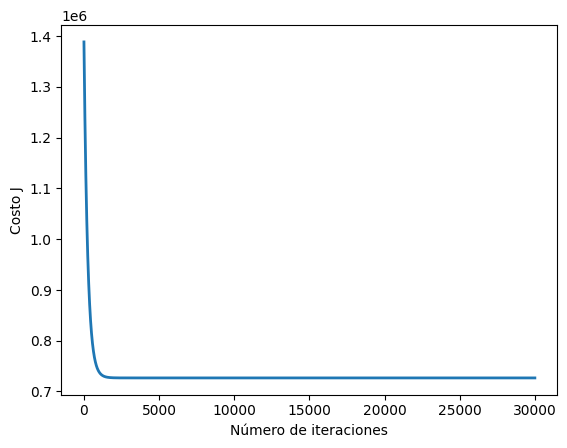

Real: 499.00 | Predicho: 938.26
Real: 799.00 | Predicho: 938.57
Real: 299.00 | Predicho: 936.88
Real: 999.00 | Predicho: 937.77
Real: 499.00 | Predicho: 937.68
Real: 0.00 | Predicho: 936.89
Real: 1999.00 | Predicho: 937.91
Real: 3999.00 | Predicho: 939.63
Real: 899.00 | Predicho: 938.88
Real: 0.00 | Predicho: 937.60
Real: 199.00 | Predicho: 936.92
Real: 629.00 | Predicho: 940.05
Real: 1999.00 | Predicho: 940.63
Real: 1999.00 | Predicho: 937.25
Real: 4499.00 | Predicho: 940.69
Real: 899.00 | Predicho: 937.73
Real: 0.00 | Predicho: 937.50
Real: 1199.00 | Predicho: 939.19
Real: 999.00 | Predicho: 938.05
Real: 999.00 | Predicho: 938.73
Real: 400.00 | Predicho: 936.88
Real: 1099.00 | Predicho: 938.99
Real: 999.00 | Predicho: 936.89
Real: 299.00 | Predicho: 936.89
Real: 2999.00 | Predicho: 1560.66
Real: 499.00 | Predicho: 937.36
Real: 199.00 | Predicho: 937.62
Real: 1499.00 | Predicho: 937.85
Real: 599.00 | Predicho: 937.03
Real: 0.00 | Predicho: 942.53
Real: 399.00 | Predicho: 937.00
Real: 

In [10]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.002  # también puedes probar alpha = 0.003 #learning rate 0.001
num_iters = 30000

# X ya contiene la columna de 1s (bias) de la celda anterior (6Ys7XcNsYaEo)
# y está normalizado. No es necesario añadirla de nuevo.
# X = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])  # ahora coincide con el número de columnas
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.show()

# === ESTIMAR para los últimos 100 valores de tu dataset ===
X_last = X[-100:]
y_last = y[-100:]
y_pred_last = X_last.dot(theta)

# Mostrar comparaciones de los primeros 100
for real, pred in zip(y_last[:100], y_pred_last[:100]):
    print(f"Real: {real:.2f} | Predicho: {pred:.2f}")

# Calcular MSE manualmente
errors = y_last - y_pred_last
mse = np.mean(errors ** 2)

# Calcular R² manualmente
ss_res = np.sum(errors ** 2)                              # suma de residuos al cuadrado
ss_tot = np.sum((y_last - np.mean(y_last)) ** 2)          # suma total de cuadrados
r2 = 1 - (ss_res / ss_tot)

print("MSE últimos 100:", mse)
print("R² últimos 100:", r2)

#Ecuación de la normal

---

La ecuación de la normal ofrece una solución directa al problema de regresión lineal múltiple sin necesidad de iteraciones. Mediante operaciones matriciales se obtiene un conjunto de parámetros que minimizan el error cuadrático medio. Aunque este método evita el descenso de gradiente, puede ser computacionalmente costoso en conjuntos de datos muy grandes

In [11]:
# Cargar datos: Revertido a 'regsimple.csv' según su indicación.
data = pd.read_csv('/content/drive/MyDrive/machine learning/laboratorio/regsimple.csv', delimiter=',')

# Seleccionar características relevantes para 'regsimple.csv' (dataset de Steam)
selected_columns = ['positive', 'negative', 'metacritic_score', 'achievements', 'price']
data = data[selected_columns]

# Convertir columnas numéricas que puedan tener formato de texto y manejar nulos
for col in ['positive', 'negative', 'metacritic_score', 'achievements', 'price']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Eliminar filas con valores NaN en la columna objetivo 'price'
data = data.dropna(subset=['price'])
data = data.fillna(0) # Rellenar nulos restantes con 0

# Considerar solo los primeros 10100 registros como antes
data = data.head(10100)

X = data[['positive', 'negative', 'metacritic_score', 'achievements']]
y = data['price']
m = y.size
print(f"Número de ejemplos de entrenamiento: {m}")
X = np.concatenate([np.ones((m, 1)), X], axis=1)

Número de ejemplos de entrenamiento: 10100


In [12]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [13]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar pm2.5 para los últimos 100 registros
X_array = X[-100:]          # últimos 100 registros
y_pred_last = np.dot(X_array, theta)

# Mostrar primeras 10 predicciones
for i in range(10):
    print(f"Real: {y.values[-100:][i]:.2f} | Predicho: {y_pred_last[i]:.2f}")

Theta calculado a partir de la ecuación de la normal: [ 9.36884192e+02  6.01946410e-04 -1.85943067e-04  8.18586818e+00
  4.95710991e-02]
Real: 499.00 | Predicho: 938.26
Real: 799.00 | Predicho: 938.57
Real: 299.00 | Predicho: 936.88
Real: 999.00 | Predicho: 937.77
Real: 499.00 | Predicho: 937.68
Real: 0.00 | Predicho: 936.89
Real: 1999.00 | Predicho: 937.91
Real: 3999.00 | Predicho: 939.63
Real: 899.00 | Predicho: 938.88
Real: 0.00 | Predicho: 937.60


#Regresión Polinómica

---



La regresión polinómica amplía el modelo lineal al incluir potencias de las variables originales. Esto permite capturar relaciones no lineales y obtener un ajuste más flexible cuando los datos no siguen un patrón lineal simple. El procedimiento de entrenamiento es similar al de la regresión múltiple, pero considerando estos nuevos términos en la matriz de entrada

In [14]:
import pandas as pd
import numpy as np

# Cargar datos: Revertido a 'regsimple.csv' según su indicación, para inspeccionar columnas.
data = pd.read_csv('/content/drive/MyDrive/machine learning/laboratorio/regsimple.csv')

print("Columnas disponibles en regsimple.csv:")
print(data.columns.tolist())

# 1. Seleccionar las columnas relevantes (numéricas y objetivo)
# Ajusta las columnas según las que necesites analizar
# Basado en las columnas disponibles en regsimple.csv (dataset de Steam)
columnas_interes = ['positive', 'negative', 'metacritic_score', 'achievements', 'price']
data = data[columnas_interes]

# 2. Convertir columnas numéricas que puedan tener formato de texto
for col in ['positive', 'negative', 'metacritic_score', 'achievements', 'price']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# 3. Eliminar filas con valores nulos en la variable objetivo o características
data = data.dropna(subset=['price']) # 'price' es la variable objetivo
data = data.fillna(0) # Opcional: rellenar nulos restantes en X con 0

# 4. Limitar opcionalmente el tamaño de los datos
data = data.head(10100)

# 5. Separar características (X) y variable objetivo (y)
X = data[['positive', 'negative', 'metacritic_score', 'achievements']]
y = data['price']

# 6. Obtener el número de ejemplos (m)
m = y.size
print("Número de ejemplos (m):", m)

Columnas disponibles en regsimple.csv:
['appid', 'name', 'developer', 'publisher', 'positive', 'negative', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'release_date', 'required_age', 'is_free', 'short_description', 'supported_languages', 'platforms_windows', 'platforms_mac', 'platforms_linux', 'metacritic_score', 'recommendations', 'achievements', 'genres', 'categories']
Número de ejemplos (m): 10100


In [15]:
X = np.concatenate([X, X*X], axis=1)  # ahora cada feature tiene su cuadrado


In [16]:
print(X)

[[7.64208400e+06 1.17300300e+06 0.00000000e+00 ... 1.37593604e+12
  0.00000000e+00 1.00000000e+00]
 [6.68053000e+05 3.26926000e+05 8.80000000e+01 ... 1.06880609e+11
  7.74400000e+03 1.44000000e+02]
 [1.52045700e+06 1.03748700e+06 0.00000000e+00 ... 1.07637928e+12
  0.00000000e+00 1.36900000e+03]
 ...
 [2.30000000e+02 2.04000000e+02 0.00000000e+00 ... 4.16160000e+04
  0.00000000e+00 0.00000000e+00]
 [6.58000000e+02 4.20000000e+01 0.00000000e+00 ... 1.76400000e+03
  0.00000000e+00 9.00000000e+02]
 [2.74000000e+02 3.90000000e+01 0.00000000e+00 ... 1.52100000e+03
  0.00000000e+00 0.00000000e+00]]


In [17]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [18]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

#print(X)
#print('Media calculada:', mu)
#print('Desviación estandar calculada:', sigma)
#print(X_norm)

In [19]:
print(X_norm)

[[ 8.04026390e+01  6.49161593e+01 -6.08605055e-01 ...  7.86560889e+01
  -5.93089945e-01 -3.93705742e-02]
 [ 6.91294195e+00  1.80155034e+01  1.96887579e+00 ...  6.09252571e+00
   2.28208364e+00 -3.92573894e-02]
 [ 1.58952524e+01  5.74040897e+01 -6.08605055e-01 ...  6.15276754e+01
  -5.93089945e-01 -3.82877991e-02]
 ...
 [-1.24323861e-01 -9.57040748e-02 -6.08605055e-01 ... -1.88187241e-02
  -5.93089945e-01 -3.93713657e-02]
 [-1.19813759e-01 -1.04684234e-01 -6.08605055e-01 ... -1.88210028e-02
  -5.93089945e-01 -3.86590137e-02]
 [-1.23860206e-01 -1.04850533e-01 -6.08605055e-01 ... -1.88210167e-02
  -5.93089945e-01 -3.93713657e-02]]


In [20]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
#X_norm = np.concatenate([X_norm, X_norm * X_norm], axis=1)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

Descenso por el gradiente

De la misma forma que en la regresión múltiple, se aplica el descenso de gradiente para ajustar los parámetros del modelo polinómico. El error se va reduciendo con cada iteración, logrando que la curva ajustada se acerque lo más posible a los valores reales observados en el conjunto de datos

In [21]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [22]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

theta calculado por el descenso por el gradiente: [1116.00871287  116.10822156  180.39565017   22.21926821  112.93230931
  -57.43993957 -215.06009528  246.45290922 -119.91486847]
Real: 499.00 | Predicho: 915.28
Real: 799.00 | Predicho: 926.86
Real: 299.00 | Predicho: 909.59
Real: 999.00 | Predicho: 917.52
Real: 499.00 | Predicho: 918.54
Real: 0.00 | Predicho: 909.60
Real: 1999.00 | Predicho: 919.68
Real: 3999.00 | Predicho: 938.46
Real: 899.00 | Predicho: 924.92
Real: 0.00 | Predicho: 917.44


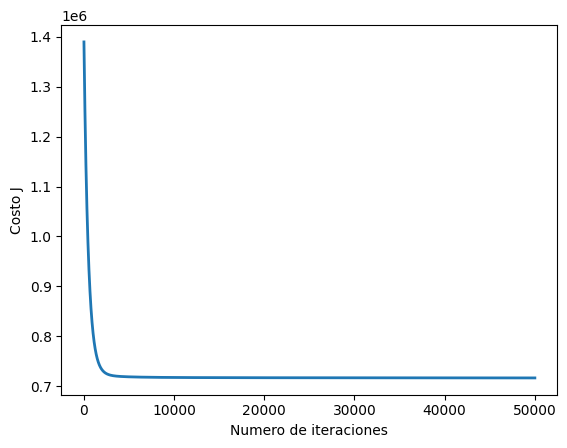

In [23]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 50000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))


# Estimar pm2.5 para los últimos 100 registros
X_array = X[-100:]          # últimos 100 registros
y_pred_last = np.dot(X_array, theta)

# Mostrar primeras 10 predicciones
for i in range(10):
    print(f"Real: {y.values[-100:][i]:.2f} | Predicho: {y_pred_last[i]:.2f}")

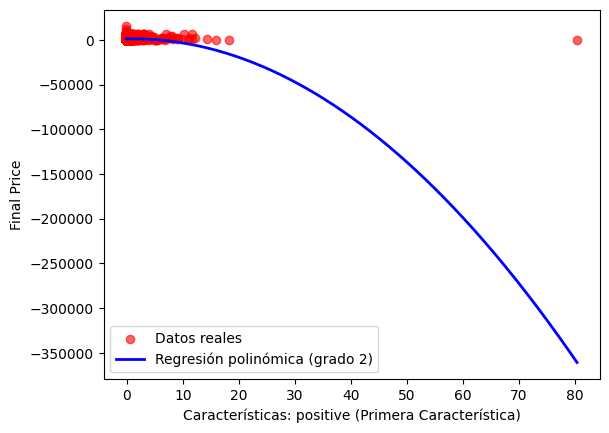

In [24]:
def plotPolyDataset(X, y, theta, degree=2):
    """
    Grafica los puntos reales del dataset y la curva polinómica ajustada
    sobre la primera característica de X (después del término de bias).
    Nota: Esta visualización es para una sola característica y no representa
    la complejidad total de la regresión polinómica con múltiples variables.
    """
    # Tomamos la primera variable real de X (excluyendo el 1 de bias)
    # Si X_norm se concatenó con np.ones, entonces X[:, 1] es la primera característica.
    x_feature_to_plot = X[:, 1] # Asume que la primera característica real es la de interés para el plot

    pyplot.scatter(x_feature_to_plot, y, color='red', label="Datos reales", alpha=0.6)

    # Generar valores ordenados para la curva
    x_plot = np.linspace(min(x_feature_to_plot), max(x_feature_to_plot), 300)

    # Construir matriz polinómica para x_plot para UNA característica
    # Esto asume que solo estamos graficando la relación de 'x_feature_to_plot' con 'y'
    # y no el efecto combinado de todas las características polinómicas.
    X_poly_plot = np.ones((len(x_plot), 1))
    for d in range(1, degree + 1):
        X_poly_plot = np.concatenate([X_poly_plot, (x_plot ** d).reshape(-1, 1)], axis=1)

    # Para la predicción, necesitamos un 'theta' que corresponda solo a esta característica
    # o un theta adaptado para la visualización 1D. La forma actual de 'theta' es para múltiples características.
    # Por simplicidad y para mantener la compatibilidad con el 'theta' global,
    # esta gráfica puede no ser una representación exacta de la predicción global del modelo polinómico.
    # Solo muestra la tendencia de la primera característica.

    # Si theta tiene más términos de los que se pueden graficar en 1D, esta aproximación es limitada.
    # Para una visualización más precisa de un modelo de múltiples variables,
    # se necesitarían métodos de visualización más complejos o la fijación de otras variables.
    # Aquí, solo estamos graficando el impacto de la primera característica del dataset.

    # Dado que theta fue calculado con múltiples características, y luego expandido polinómicamente
    # para *todas* las características, esta visualización simplificada solo toma el primer término polinómico
    # para la característica 'X[:,1]' y el término de bias.
    # Esto es una limitación de la función de trazado 1D en un contexto de regresión multi-variable polinómica.

    # Si 'theta' tiene la forma (1 + num_features * degree), y estamos trazando contra 'X[:,1]',
    # estamos haciendo una simplificación. Si queremos mostrar la curva de regresión real de UNA característica
    # mientras las demás se mantienen constantes (ej. en su media), el cálculo sería más complejo.
    # Para este plot, usaremos una aproximación simple para 'theta' que asume que solo el término de bias
    # y los términos polinómicos de la primera característica son relevantes para esta visualización.

    # Una aproximación para theta relevante para la gráfica 1D:
    # El `theta` del modelo completo tiene `1 + num_features + num_features` elementos.
    # theta[0] es el bias.
    # theta[1] es el coeficiente de la primera característica original (X[:,1]).
    # theta[1 + num_features] es el coeficiente del cuadrado de la primera característica original.
    num_original_features = (X.shape[1] - 1) // 2 # Asumiendo que se añadieron X y X*X
    if num_original_features > 0:
        theta_for_plot = np.array([theta[0], theta[1], theta[1 + num_original_features]])
    else:
        theta_for_plot = np.array([theta[0], theta[1]]) # Si solo hay una característica original

    # Asegurarse de que X_poly_plot y theta_for_plot coincidan en dimensiones
    # Esto es una simplificación y puede no representar el modelo completo correctamente.
    y_plot = np.dot(X_poly_plot[:, :len(theta_for_plot)], theta_for_plot)

    # Dibujar la curva ajustada
    pyplot.plot(x_plot, y_plot, 'b-', linewidth=2, label=f'Regresión polinómica (grado {degree})')

    pyplot.xlabel(f"Características: {data.columns[0]} (Primera Característica)") # Adaptar el label
    pyplot.ylabel("Final Price") # Adaptar el label
    pyplot.legend()
    pyplot.show()

# Uso con tu dataset (ejemplo para grado 2)
# El plot será una simplificación, mostrando la relación de la primera característica
# (positive_ratings) con 'final_price' en el contexto del modelo polinómico.
plotPolyDataset(X, y, theta, degree=2)

Ecuación de la Normal

---



También es posible aplicar la ecuación de la normal al caso polinómico. El principio es el mismo: calcular de forma matricial los parámetros que minimizan el error. Este método evita las iteraciones, pero al incluir muchos términos polinómicos puede volverse pesado en cuanto a cálculos y memoria

In [25]:
#data = pd.read_csv('/content/drive/MyDrive/sis420/machine_learning/datasets/steam.csv')
data = pd.read_csv('/content/drive/MyDrive/machine learning/laboratorio/regsimple.csv')

# Seleccionar las columnas correctas del dataset de Steam
selected_columns = ['positive', 'negative', 'metacritic_score', 'achievements', 'price']
data = data[selected_columns]

# Convertir columnas numéricas que puedan tener formato de texto y manejar nulos
for col in ['positive', 'negative', 'metacritic_score', 'achievements', 'price']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['price']) # Eliminar filas con NaN en la variable objetivo 'price'
data = data.fillna(0) # Rellenar nulos restantes en X con 0

# Limitar el tamaño de los datos como en las celdas anteriores
data = data.head(10100)

X = data[['positive', 'negative', 'metacritic_score', 'achievements']].values
y = data['price'].values
m = y.size

# Añadir características polinómicas (cuadrados)
X = np.concatenate([X, X * X], axis=1)
# Añadir el término de bias (intercepto)
X = np.concatenate([np.ones((m, 1)), X], axis=1)

In [26]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [27]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar pm2.5 para los últimos 100 registros
X_array = X[-100:]          # últimos 100 registros
y_pred_last = np.dot(X_array, theta)

# Mostrar primeras 10 predicciones
for i in range(100):
    print(f"Real: {y[-100:][i]:.2f} | Predicho: {y_pred_last[i]:.2f}")

Theta calculado a partir de la ecuación de la normal: [ 9.13378819e+02  9.11005555e-04  1.15383564e-02 -6.69910812e+00
  5.18399266e-01 -5.31422147e-11 -1.37253344e-08  1.85212675e-01
 -9.53737554e-05]
Real: 499.00 | Predicho: 918.77
Real: 799.00 | Predicho: 930.82
Real: 299.00 | Predicho: 913.39
Real: 999.00 | Predicho: 921.36
Real: 499.00 | Predicho: 922.57
Real: 0.00 | Predicho: 913.40
Real: 1999.00 | Predicho: 923.55
Real: 3999.00 | Predicho: 942.81
Real: 899.00 | Predicho: 928.49
Real: 0.00 | Predicho: 921.76
Real: 199.00 | Predicho: 914.19
Real: 629.00 | Predicho: 945.15
Real: 1999.00 | Predicho: 940.73
Real: 1999.00 | Predicho: 920.95
Real: 4499.00 | Predicho: 951.60
Real: 899.00 | Predicho: 922.16
Real: 0.00 | Predicho: 918.55
Real: 1199.00 | Predicho: 937.16
Real: 999.00 | Predicho: 923.56
Real: 999.00 | Predicho: 931.62
Real: 400.00 | Predicho: 913.38
Real: 1099.00 | Predicho: 935.60
Real: 999.00 | Predicho: 913.42
Real: 299.00 | Predicho: 913.42
Real: 2999.00 | Predicho: 148